# Debug Notebook: `rimplane` Opening Losses

Dieses Notebook erklaert die Opening-Losses im aktuellen `rimplane`-Pfad direkt am Mesh.

Gezeigt werden:
- `loss_openings_p`: Rim-zu-Rim-Punktabstand
- `loss_openings_n`: Ebenen-Normalen-Ausrichtung
- `loss_openings_plane`: Abstand der Opening-Vertices zur Ziel-Ebene
- `loss_openings_surface_p`: Abstand zur reparierten Target-Cap

Die Visualisierungen basieren auf einem echten vorbereiteten Fall aus `/data/ghd_prepared_meshes_3_aneurysm_1op_new`. Zusaetzlich werden kuenstlich verfaelschte Opening-Varianten erzeugt, damit klar ist, **was der jeweilige Loss bestraft**.


In [1]:
from pathlib import Path
import pickle
import math

import numpy as np
import pandas as pd
import trimesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection


In [2]:
ROOT = Path('/data/ghd_prepared_meshes_3_aneurysm_1op_new')
CASE_NAME = 'item_Case7'
CKPT = ROOT / CASE_NAME / 'opa_checkpoint_1op.pkl'
MESH_PATH = ROOT / CASE_NAME / 'part_aligned.obj'
assert CKPT.is_file(), CKPT
assert MESH_PATH.is_file(), MESH_PATH
print(CKPT)
print(MESH_PATH)


/data/ghd_prepared_meshes_3_aneurysm_1op_new/item_Case7/opa_checkpoint_1op.pkl
/data/ghd_prepared_meshes_3_aneurysm_1op_new/item_Case7/part_aligned.obj


In [3]:
with open(CKPT, 'rb') as f:
    chk = pickle.load(f)

target_mesh = trimesh.load(str(MESH_PATH), process=False)

rim = np.asarray((chk.get('op_target_rim_v') or chk.get('op_v_coords'))[0], dtype=np.float64)
cap_v = np.asarray((chk.get('op_target_rec_v') or chk.get('op_rec_v'))[0], dtype=np.float64)
cap_f = np.asarray((chk.get('op_target_rec_f') or chk.get('op_rec_f'))[0], dtype=np.int64)
plane_center = np.asarray((chk.get('op_target_plane_center') or [rim.mean(axis=0)])[0], dtype=np.float64).reshape(3)
plane_normal = np.asarray((chk.get('op_target_plane_normal') or chk.get('op_n_mean'))[0], dtype=np.float64).reshape(3)
plane_normal = plane_normal / max(np.linalg.norm(plane_normal), 1e-12)
debug = (chk.get('op_target_debug') or [{}])[0]
source_kind = (chk.get('op_source_kind') or ['unknown'])[0]

print('case           :', CASE_NAME)
print('source_kind    :', source_kind)
print('debug stage    :', debug.get('stage'))
print('cap verts/faces:', cap_v.shape, cap_f.shape)
print('rim points     :', rim.shape)


case           : item_Case7
source_kind    : ostium_pointcloud
debug stage    : repair_ordered
cap verts/faces: (385, 3) (640, 3)
rim points     : (128, 3)


In [4]:
def plane_basis_from_normal(normal):
    n = np.asarray(normal, dtype=np.float64).reshape(3)
    n = n / max(np.linalg.norm(n), 1e-12)
    helper = np.array([1.0, 0.0, 0.0]) if abs(n[0]) < 0.9 else np.array([0.0, 1.0, 0.0])
    u = np.cross(n, helper)
    u = u / max(np.linalg.norm(u), 1e-12)
    v = np.cross(n, u)
    v = v / max(np.linalg.norm(v), 1e-12)
    return u, v

def plane_from_points(points):
    pts = np.asarray(points, dtype=np.float64).reshape(-1, 3)
    c = pts.mean(axis=0)
    x = pts - c.reshape(1, 3)
    _, _, vh = np.linalg.svd(x, full_matrices=False)
    n = vh[-1]
    n = n / max(np.linalg.norm(n), 1e-12)
    return c, n

def sample_boundary_points(verts, faces, n=256, seed=0):
    verts = np.asarray(verts, dtype=np.float64)
    faces = np.asarray(faces, dtype=np.int64)
    edges = np.concatenate([faces[:, [0,1]], faces[:, [1,2]], faces[:, [2,0]]], axis=0)
    edges = np.sort(edges, axis=1)
    uniq, counts = np.unique(edges, axis=0, return_counts=True)
    boundary_edges = uniq[counts == 1]
    if boundary_edges.shape[0] == 0:
        pts = verts
    else:
        pts = verts[np.unique(boundary_edges.reshape(-1))]
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, pts.shape[0], size=max(1, int(n)))
    return pts[idx]

def chamfer_mean(a, b):
    a = np.asarray(a, dtype=np.float64)
    b = np.asarray(b, dtype=np.float64)
    d = np.linalg.norm(a[:, None, :] - b[None, :, :], axis=2)
    return 0.5 * (d.min(axis=1).mean() + d.min(axis=0).mean())

def opening_plane_normal_loss(verts, target_normal):
    _, n = plane_from_points(verts)
    dot = float(np.clip(abs(np.dot(n, target_normal)), -1.0, 1.0))
    return 1.0 - dot

def opening_planarity_loss(verts, target_center, target_normal):
    verts = np.asarray(verts, dtype=np.float64)
    c_self, n_self = plane_from_points(verts)
    self_dist = (verts - c_self.reshape(1, 3)) @ n_self
    target_dist = (verts - target_center.reshape(1, 3)) @ target_normal
    return 0.5 * ((self_dist ** 2).mean() + (target_dist ** 2).mean())

def shift_in_plane(points, normal, delta_u=0.0, delta_v=0.0):
    u, v = plane_basis_from_normal(normal)
    shift = delta_u * u + delta_v * v
    return np.asarray(points, dtype=np.float64) + shift.reshape(1, 3)

def tilt_points(points, center, axis, degrees):
    pts = np.asarray(points, dtype=np.float64)
    axis = np.asarray(axis, dtype=np.float64).reshape(3)
    axis = axis / max(np.linalg.norm(axis), 1e-12)
    theta = np.deg2rad(float(degrees))
    K = np.array([[0, -axis[2], axis[1]], [axis[2], 0, -axis[0]], [-axis[1], axis[0], 0]], dtype=np.float64)
    R = np.eye(3) + math.sin(theta) * K + (1.0 - math.cos(theta)) * (K @ K)
    return (pts - center.reshape(1,3)) @ R.T + center.reshape(1,3)

def warp_out_of_plane(points, normal, amp=0.03):
    pts = np.asarray(points, dtype=np.float64).copy()
    n = normal / max(np.linalg.norm(normal), 1e-12)
    t = np.linspace(0.0, 2.0*np.pi, pts.shape[0], endpoint=False)
    offset = (amp * np.sin(2.0 * t)).reshape(-1, 1) * n.reshape(1, 3)
    return pts + offset

def draw_mesh(ax, mesh, color='lightgray', alpha=0.12):
    verts = np.asarray(mesh.vertices, dtype=np.float64)
    faces = np.asarray(mesh.faces, dtype=np.int64)
    tris = verts[faces]
    coll = Poly3DCollection(tris, facecolor=color, edgecolor='none', alpha=alpha)
    ax.add_collection3d(coll)

def draw_opening(ax, verts, faces, face_color='gold', edge_color='black', alpha=0.18, lw=0.4):
    tris = np.asarray(verts, dtype=np.float64)[np.asarray(faces, dtype=np.int64)]
    coll = Poly3DCollection(tris, facecolor=face_color, edgecolor=edge_color, linewidth=lw, alpha=alpha)
    ax.add_collection3d(coll)

def draw_rim(ax, rim_points, color='red', s=6, label=None):
    pts = np.asarray(rim_points, dtype=np.float64)
    ax.scatter(pts[:,0], pts[:,1], pts[:,2], color=color, s=s, depthshade=False, label=label)

def draw_plane_disk(ax, center, normal, rim_points, color='royalblue', alpha=0.10, edge_color='navy'):
    center = np.asarray(center, dtype=np.float64).reshape(3)
    normal = np.asarray(normal, dtype=np.float64).reshape(3)
    u, v = plane_basis_from_normal(normal)
    rel = np.asarray(rim_points, dtype=np.float64) - center.reshape(1, 3)
    pts2 = np.stack([rel @ u, rel @ v], axis=1)
    r = np.sqrt((pts2 ** 2).sum(axis=1)).max()
    t = np.linspace(0.0, 2.0*np.pi, 72, endpoint=False)
    ring = center.reshape(1,3) + r*np.cos(t).reshape(-1,1)*u.reshape(1,3) + r*np.sin(t).reshape(-1,1)*v.reshape(1,3)
    fan = []
    for i in range(ring.shape[0]):
        j = (i + 1) % ring.shape[0]
        fan.append(np.stack([center, ring[i], ring[j]], axis=0))
    coll = Poly3DCollection(fan, facecolor=color, edgecolor=edge_color, linewidth=0.2, alpha=alpha)
    ax.add_collection3d(coll)

def draw_normals(ax, points, normals, color='magenta', length=0.08):
    pts = np.asarray(points, dtype=np.float64)
    n = np.asarray(normals, dtype=np.float64)
    ax.quiver(pts[:,0], pts[:,1], pts[:,2], n[:,0], n[:,1], n[:,2], length=length, normalize=True, color=color, linewidths=0.8)

def set_equal_aspect(ax, arrays):
    valid = [np.asarray(a, dtype=np.float64).reshape(-1, 3) for a in arrays if a is not None and np.asarray(a).size > 0]
    pts = np.concatenate(valid, axis=0)
    mn = pts.min(axis=0)
    mx = pts.max(axis=0)
    center = 0.5 * (mn + mx)
    radius = 0.55 * np.max(mx - mn)
    ax.set_xlim(center[0] - radius, center[0] + radius)
    ax.set_ylim(center[1] - radius, center[1] + radius)
    ax.set_zlim(center[2] - radius, center[2] + radius)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')


In [5]:
# Geometrien fuer die Demonstration
base_v = cap_v.copy()
base_f = cap_f.copy()
base_rim = rim.copy()

# 1) loss_openings_p: Rim in der Ebene verschoben
p_shift_rim = shift_in_plane(base_rim, plane_normal, delta_u=0.05, delta_v=-0.03)
p_shift_v = shift_in_plane(base_v, plane_normal, delta_u=0.05, delta_v=-0.03)

# 2) loss_openings_n: Oeffnung gekippt
u_axis, _ = plane_basis_from_normal(plane_normal)
n_tilt_v = tilt_points(base_v, plane_center, u_axis, degrees=18.0)
n_tilt_rim = tilt_points(base_rim, plane_center, u_axis, degrees=18.0)

# 3) loss_openings_plane: Oeffnung aus der Ebene heraus gewellt
plane_bad_v = warp_out_of_plane(base_v, plane_normal, amp=0.025)
plane_bad_rim = warp_out_of_plane(base_rim, plane_normal, amp=0.012)

# 4) loss_openings_surface_p: innere Flaeche verschoben
surface_bad_v = plane_center.reshape(1,3) + 0.72 * (base_v - plane_center.reshape(1,3))

base_boundary = sample_boundary_points(base_v, base_f, n=256, seed=1)
p_shift_boundary = sample_boundary_points(p_shift_v, base_f, n=256, seed=1)
n_tilt_boundary = sample_boundary_points(n_tilt_v, base_f, n=256, seed=1)
plane_bad_boundary = sample_boundary_points(plane_bad_v, base_f, n=256, seed=1)
surface_bad_boundary = sample_boundary_points(surface_bad_v, base_f, n=256, seed=1)

losses = {
    'base': {
        'loss_openings_p': chamfer_mean(base_boundary, base_rim),
        'loss_openings_n': opening_plane_normal_loss(base_v, plane_normal),
        'loss_openings_plane': opening_planarity_loss(base_v, plane_center, plane_normal),
        'loss_openings_surface_p': chamfer_mean(base_v, cap_v),
    },
    'p_shift': {
        'loss_openings_p': chamfer_mean(p_shift_boundary, base_rim),
        'loss_openings_n': opening_plane_normal_loss(p_shift_v, plane_normal),
        'loss_openings_plane': opening_planarity_loss(p_shift_v, plane_center, plane_normal),
        'loss_openings_surface_p': chamfer_mean(p_shift_v, cap_v),
    },
    'n_tilt': {
        'loss_openings_p': chamfer_mean(n_tilt_boundary, base_rim),
        'loss_openings_n': opening_plane_normal_loss(n_tilt_v, plane_normal),
        'loss_openings_plane': opening_planarity_loss(n_tilt_v, plane_center, plane_normal),
        'loss_openings_surface_p': chamfer_mean(n_tilt_v, cap_v),
    },
    'plane_bad': {
        'loss_openings_p': chamfer_mean(plane_bad_boundary, base_rim),
        'loss_openings_n': opening_plane_normal_loss(plane_bad_v, plane_normal),
        'loss_openings_plane': opening_planarity_loss(plane_bad_v, plane_center, plane_normal),
        'loss_openings_surface_p': chamfer_mean(plane_bad_v, cap_v),
    },
    'surface_bad': {
        'loss_openings_p': chamfer_mean(surface_bad_boundary, base_rim),
        'loss_openings_n': opening_plane_normal_loss(surface_bad_v, plane_normal),
        'loss_openings_plane': opening_planarity_loss(surface_bad_v, plane_center, plane_normal),
        'loss_openings_surface_p': chamfer_mean(surface_bad_v, cap_v),
    },
}
losses


{'base': {'loss_openings_p': 0.02054357135399803,
  'loss_openings_n': 0.0,
  'loss_openings_plane': 2.936465005581178e-35,
  'loss_openings_surface_p': 0.0},
 'p_shift': {'loss_openings_p': 0.04573209975118471,
  'loss_openings_n': 0.0,
  'loss_openings_plane': 4.730476989894758e-35,
  'loss_openings_surface_p': 0.023960661002854926},
 'n_tilt': {'loss_openings_p': 0.02561974078650622,
  'loss_openings_n': 0.04894348370484625,
  'loss_openings_plane': 0.00017353813496048744,
  'loss_openings_surface_p': 0.016319659823496112},
 'plane_bad': {'loss_openings_p': 0.02383380687854985,
  'loss_openings_n': 0.0010922783530479263,
  'loss_openings_plane': 0.000311236636872552,
  'loss_openings_surface_p': 0.014200829000513657},
 'surface_bad': {'loss_openings_p': 0.03160797144666737,
  'loss_openings_n': 0.0,
  'loss_openings_plane': 1.2802523295080434e-34,
  'loss_openings_surface_p': 0.00902721570222231}}

## 1. Zielgeometrie im aktuellen `rimplane`-Pfad

Diese Ansicht zeigt, **woraus die Supervision besteht**:
- graues Mesh: `part_aligned.obj`
- rote Punkte: `target rim`
- blaue Scheibe: `target plane`
- goldene Flaeche: `target opening surface` aus der reparierten Triangulation

Wichtig: Im `rimplane`-Pfad ist der Rim die primaere Geometrie. Die innere Cap-Flaeche ist nur noch sekundaer.


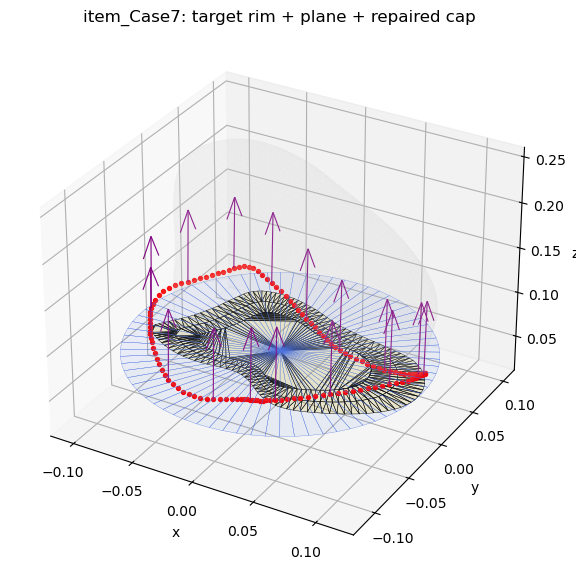

In [6]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(111, projection='3d')
draw_mesh(ax, target_mesh, color='lightgray', alpha=0.10)
draw_plane_disk(ax, plane_center, plane_normal, base_rim, color='royalblue', alpha=0.08, edge_color='royalblue')
draw_opening(ax, base_v, base_f, face_color='gold', edge_color='black', alpha=0.18, lw=0.35)
draw_rim(ax, base_rim, color='red', s=8)
sub = base_rim[::max(1, len(base_rim)//16)]
nn = np.repeat(plane_normal.reshape(1,3), sub.shape[0], axis=0)
draw_normals(ax, sub, nn, color='purple', length=0.08)
set_equal_aspect(ax, [np.asarray(target_mesh.vertices), base_v, base_rim])
ax.set_title(f'{CASE_NAME}: target rim + plane + repaired cap')
plt.show()


## 2. `loss_openings_p`: Was wird bestraft?

Dieser Loss vergleicht im `rim_plane`-Modus **nur den Boundary/Rim**:
- `warped opening rim` gegen `target rim`
- gemessen als bidirektionaler Chamfer

Hier wird die Oeffnung in der Ebene seitlich verschoben. Dadurch steigt vor allem `loss_openings_p`.


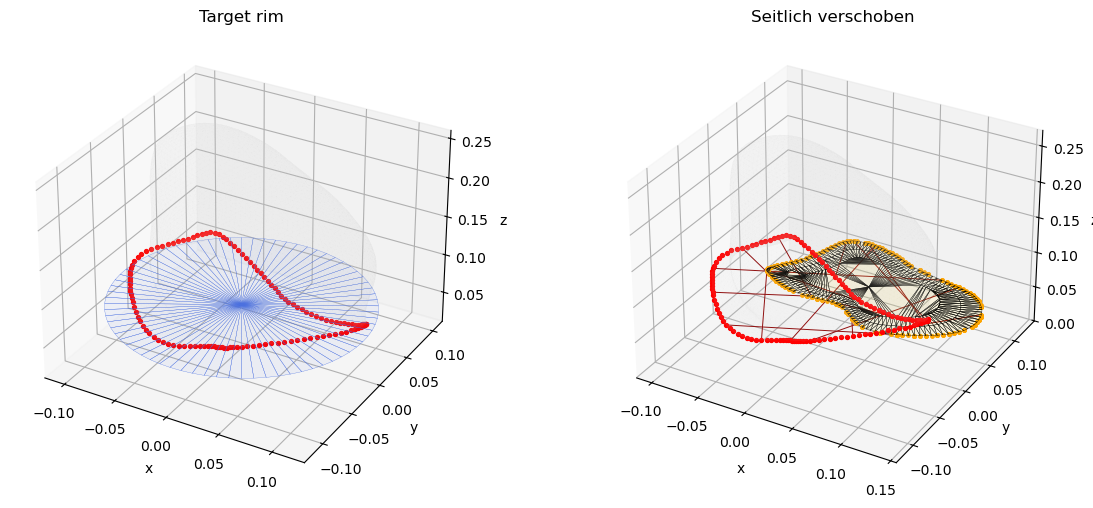

In [9]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

draw_mesh(ax1, target_mesh, color='lightgray', alpha=0.08)
draw_rim(ax1, base_rim, color='red', s=8)
draw_plane_disk(ax1, plane_center, plane_normal, base_rim, color='royalblue', alpha=0.06, edge_color='royalblue')
ax1.set_title('Target rim')
set_equal_aspect(ax1, [np.asarray(target_mesh.vertices), base_rim])

draw_mesh(ax2, target_mesh, color='lightgray', alpha=0.08)
draw_rim(ax2, base_rim, color='red', s=8)
draw_rim(ax2, p_shift_boundary, color='orange', s=6)
draw_opening(ax2, p_shift_v, base_f, face_color='gold', edge_color='black', alpha=0.10, lw=0.25)
step = max(1, len(p_shift_boundary) // 16)
for i, a in enumerate(p_shift_boundary[::step]):
    b = base_rim[(i * max(1, len(base_rim)//16)) % len(base_rim)]
    ax2.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], color='darkred', linewidth=0.7)
ax2.set_title('Seitlich verschoben')
loss_openings_p = '%.4f' % losses['p_shift']['loss_openings_p']
set_equal_aspect(ax2, [np.asarray(target_mesh.vertices), p_shift_v, base_rim])
plt.show()


**Interpretation**

Bestraft wird hier, dass der Oeffnungsrand an der falschen Position liegt.

Nicht primaer bestraft werden dabei:
- kleine innere Flaechenunterschiede
- lokale Cap-Triangulationsdetails

Primaer relevant ist: **Sitzt der Rim am richtigen Ort?**


## 3. `loss_openings_n`: Was wird bestraft?

Im `rim_plane`-Pfad ist das **kein lokaler Face-Normalen-Loss** mehr.
Stattdessen wird die **Normalenrichtung der gefitteten Oeffnungs-Ebene** mit der `target plane normal` verglichen.

Hier wird die gesamte Oeffnung gekippt. Dadurch steigt vor allem `loss_openings_n`.


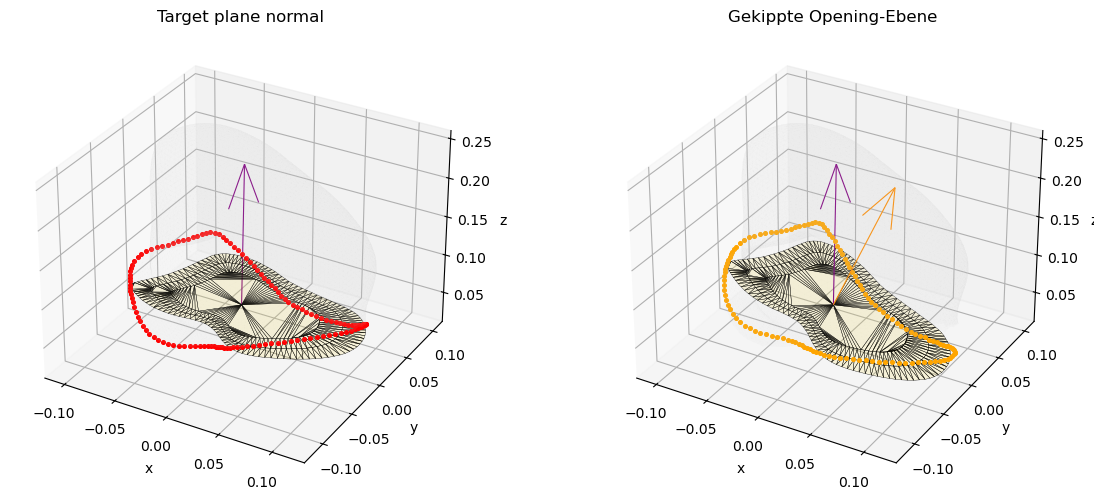

In [11]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

draw_mesh(ax1, target_mesh, color='lightgray', alpha=0.08)
draw_opening(ax1, base_v, base_f, face_color='gold', edge_color='black', alpha=0.12, lw=0.25)
draw_rim(ax1, base_rim, color='red', s=7)
draw_normals(ax1, np.array([plane_center]), np.array([plane_normal]), color='purple', length=0.18)
ax1.set_title('Target plane normal')
set_equal_aspect(ax1, [np.asarray(target_mesh.vertices), base_v])

warped_center, warped_normal = plane_from_points(n_tilt_v)
draw_mesh(ax2, target_mesh, color='lightgray', alpha=0.08)
draw_opening(ax2, n_tilt_v, base_f, face_color='gold', edge_color='black', alpha=0.12, lw=0.25)
draw_rim(ax2, n_tilt_rim, color='orange', s=7)
draw_normals(ax2, np.array([plane_center]), np.array([plane_normal]), color='purple', length=0.18)
draw_normals(ax2, np.array([warped_center]), np.array([warped_normal]), color='darkorange', length=0.18)
ax2.set_title('Gekippte Opening-Ebene')
loss_openings_n = '%.4f' % losses['n_tilt']['loss_openings_n']
set_equal_aspect(ax2, [np.asarray(target_mesh.vertices), n_tilt_v])
plt.show()


**Interpretation**

Bestraft wird hier die **Ausrichtung** der Oeffnung:
- gleiche Rim-Position allein reicht nicht
- wenn die Oeffnung in die falsche Richtung gekippt ist, steigt `loss_openings_n`

Das ist genau der Grund, warum die Plane im `rimplane`-Pfad weiter wichtig bleibt.


## 4. `loss_openings_plane`: Was wird bestraft?

Dieser Loss bestraft, dass die Opening-Vertices **nicht auf einer sauberen Ebene liegen**.
Er besteht aus zwei Teilen:
- Abweichung von der eigenen Best-Fit-Ebene
- Abweichung von der Target-Plane

Hier wird die Oeffnung wellig aus der Ebene herausgedrueckt.


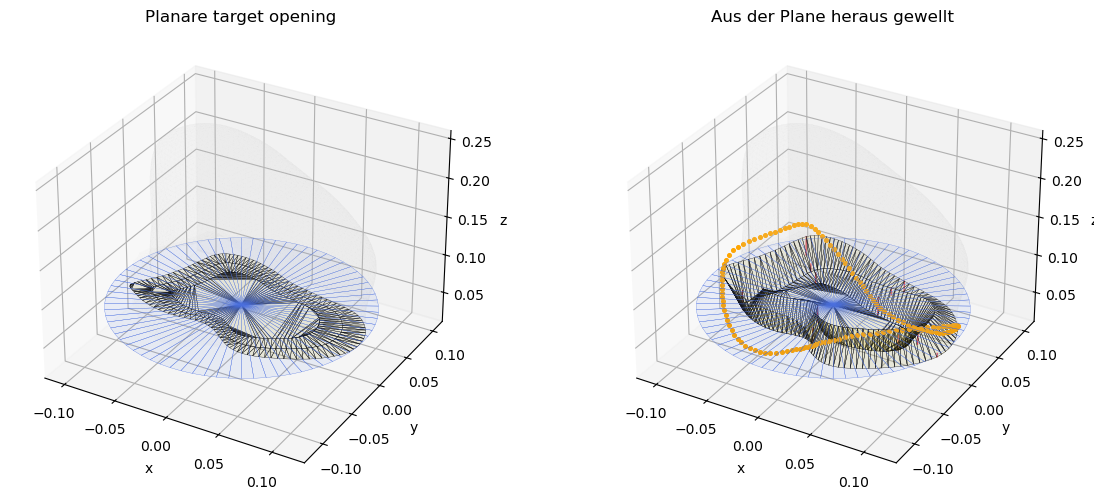

In [13]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

draw_mesh(ax1, target_mesh, color='lightgray', alpha=0.08)
draw_plane_disk(ax1, plane_center, plane_normal, base_rim, color='royalblue', alpha=0.08, edge_color='royalblue')
draw_opening(ax1, base_v, base_f, face_color='gold', edge_color='black', alpha=0.12, lw=0.25)
ax1.set_title('Planare target opening')
set_equal_aspect(ax1, [np.asarray(target_mesh.vertices), base_v])

draw_mesh(ax2, target_mesh, color='lightgray', alpha=0.08)
draw_plane_disk(ax2, plane_center, plane_normal, base_rim, color='royalblue', alpha=0.08, edge_color='royalblue')
draw_opening(ax2, plane_bad_v, base_f, face_color='gold', edge_color='black', alpha=0.12, lw=0.25)
draw_rim(ax2, plane_bad_rim, color='orange', s=7)
d = (plane_bad_v - plane_center.reshape(1,3)) @ plane_normal
sel = np.linspace(0, len(plane_bad_v)-1, 16, dtype=int)
proj = plane_bad_v[sel] - d[sel].reshape(-1,1) * plane_normal.reshape(1,3)
for a, b in zip(plane_bad_v[sel], proj):
    ax2.plot([a[0], b[0]], [a[1], b[1]], [a[2], b[2]], color='crimson', linewidth=0.8)
ax2.set_title('Aus der Plane heraus gewellt')
loss_openings_plane = '%.4f' % losses['plane_bad']['loss_openings_plane']
set_equal_aspect(ax2, [np.asarray(target_mesh.vertices), plane_bad_v])
plt.show()


**Interpretation**

Bestraft wird hier nicht primaer die Lage des Rims, sondern dass die Oeffnung als Flaeche **zu unplanar** wird.

Die roten Segmente zeigen die Abstaende der verformten Opening-Vertices zur Target-Plane.


## 5. `loss_openings_surface_p`: Was wird bestraft?

Dieser Loss bleibt im `rimplane`-Setup nur noch sekundaer.
Er vergleicht Punktwolken auf der **ganzen reparierten Target-Cap**.

Hier wird die innere Flaeche veraendert, waehrend die allgemeine Rim-Lage weniger stark veraendert wird.


In [ ]:
fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(121, projection='3d')
ax2 = fig.add_subplot(122, projection='3d')

draw_mesh(ax1, target_mesh, color='lightgray', alpha=0.08)
draw_opening(ax1, base_v, base_f, face_color='gold', edge_color='black', alpha=0.16, lw=0.25)
draw_rim(ax1, base_rim, color='red', s=7)
ax1.set_title('Target cap')
set_equal_aspect(ax1, [np.asarray(target_mesh.vertices), base_v])

draw_mesh(ax2, target_mesh, color='lightgray', alpha=0.08)
draw_opening(ax2, base_v, base_f, face_color='gold', edge_color='black', alpha=0.08, lw=0.2)
draw_opening(ax2, surface_bad_v, base_f, face_color='deepskyblue', edge_color='navy', alpha=0.14, lw=0.2)
draw_rim(ax2, base_rim, color='red', s=7)
ax2.set_title('Innere Flaeche verschoben
loss_openings_surface_p = %.4f' % losses['surface_bad']['loss_openings_surface_p'])
set_equal_aspect(ax2, [np.asarray(target_mesh.vertices), base_v, surface_bad_v])
plt.show()


**Interpretation**

Dieser Term reagiert auf Unterschiede der **inneren Cap-Flaeche**.
Im aktuellen `rimplane`-Design ist er bewusst schwach gewichtet, weil er wieder staerker von der Cap-Triangulation abhaengig ist als die Rim- und Plane-Terme.


## 6. Vergleich der numerischen Reaktion

Die Tabelle zeigt, welcher kuenstliche Fehler welchen Opening-Loss besonders stark anspricht.
Das ist keine Trainingskurve, sondern eine lokale Demonstration am aktuellen Fall.


In [ ]:
rows = []
for name, vals in losses.items():
    row = {'example': name}
    row.update({k: float(v) for k, v in vals.items()})
    rows.append(row)
df = pd.DataFrame(rows).set_index('example')
df


## 7. Praktische Lesart fuer deinen Fit

Im aktuellen `rimplane`-Pfad gilt:
- `loss_openings_p`: Rim sitzt falsch
- `loss_openings_n`: Oeffnung ist falsch gekippt
- `loss_openings_plane`: Oeffnung ist zu wellig / nicht planar
- `loss_openings_surface_p`: innere Cap stimmt nicht gut mit der reparierten Target-Cap ueberein

Damit kannst du im Preview gezielter lesen, **welcher geometrische Fehler** gerade noch offen ist.
